# Eye Tracking benchmark: 2. Descriptive analysis of the reference table

This notebook describes the completed Eye Tracking benchmark. It does not fit or evaluate the adaptive selector. Its role is to make benchmark composition and the method-outcome landscape transparent before confirmatory evaluation.


## Interpretation and estimand

For each artificial gap, the *offline oracle* is the registered candidate method with the lowest realised locally normalised RMSE (nRMSE). It describes outcome heterogeneity, but it is not deployable because it uses the concealed gap truth.

Eye-Tracking nRMSE is locally normalised using the fold-appropriate positive IQR floor; coordinates remain in their native source units. Lower nRMSE values are better. The adaptive selector is assessed only on held-out datasets in notebook 3.


In [1]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'pyproject.toml').is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Start Jupyter from inside the repository.')
    PROJECT_ROOT = PROJECT_ROOT.parent

# Read ignored workstation paths without placing them in this notebook.
source_root = str(PROJECT_ROOT / 'src')
if source_root not in sys.path:
    sys.path.insert(0, source_root)
from gap_imputation_benchmark.domains.eyetracking import EYE_TRACKING_DOMAIN
from gap_imputation_benchmark.evaluation import (
    plot_coverage,
    plot_mean_method_error,
    plot_oracle_distribution,
    plot_oracle_frequency,
)
from gap_imputation_benchmark.paths import load_local_environment, local_path_or_default
# The local .env file is authoritative for this workstation notebook.
load_local_environment(override=True)

BENCHMARK_DIR = local_path_or_default(
    'EYE_TRACKING_BENCHMARK_DIR', PROJECT_ROOT / 'benchmarks' / 'eyetracking',
)
gaps = pd.read_csv(BENCHMARK_DIR / 'learnable_gap_table.csv')
coverage = pd.read_csv(BENCHMARK_DIR / 'coverage_table.csv')
METHODS = tuple(EYE_TRACKING_DOMAIN.methods)
METHOD_LABELS = EYE_TRACKING_DOMAIN.method_labels
ORACLE_COLUMN = 'best_method_by_nrmse'
assert gaps['gap_id'].is_unique
assert gaps[ORACLE_COLUMN].isin(METHODS).all()
print(f'{len(gaps):,} learnable gaps across {gaps.dataset_id.nunique()} datasets')

1,599 learnable gaps across 4 datasets


## Benchmark coverage and sampling balance

Coverage is aggregated by dataset, the outer evaluation unit. The table shows both requested and successful gaps; a non-zero `shortfall` or `excluded_gaps` value records a failure of the fixed eligibility rule rather than a silent protocol change.


,dataset_id,requested_gaps,learnable_gaps,excluded_gaps
0,GazeBase,400,400,0
1,GazeBaseVR,400,400,0
2,Pedrotti,400,399,1
3,ZuCo,400,400,0


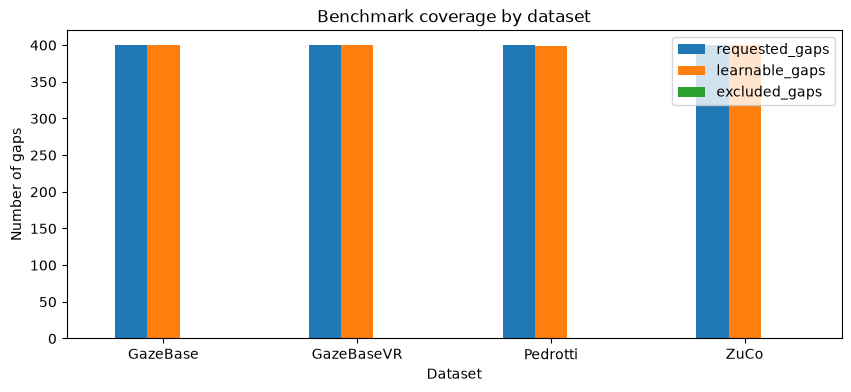

In [2]:
display(coverage)
plot_coverage(coverage)
plt.show()

## Offline-oracle patterns

The overall chart shows which method is most often best in retrospect. The dataset-level view is a diagnostic for domain shift; the duration-stratum view shows how preferred methods vary with gap length.

These summaries are descriptive results for artificial gaps. They are not estimates of the performance of the trained selector or of real missing intervals.


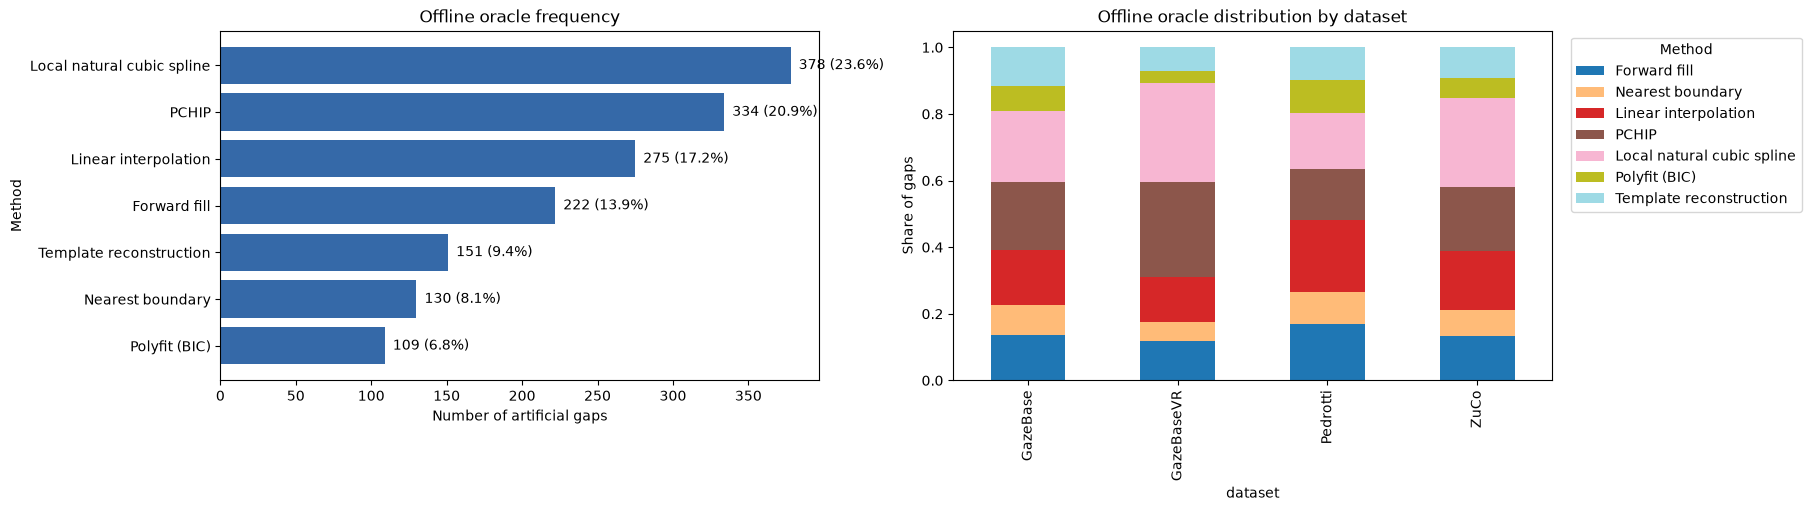

best_method_by_nrmse,forward_fill,nearest_boundary,linear,pchip,local_natural_cubic_spline,polyfit_bic,template
dataset_id,,,,,,,
GazeBase,13.8,9.0,16.2,20.5,21.2,7.5,11.8
GazeBaseVR,11.8,5.8,13.5,28.5,29.8,3.8,7.0
Pedrotti,16.8,9.8,21.6,15.3,16.8,10.0,9.8
ZuCo,13.2,8.0,17.5,19.2,26.8,6.0,9.2


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
plot_oracle_frequency(gaps, METHODS, oracle_column=ORACLE_COLUMN, method_labels=METHOD_LABELS, ax=axes[0])
_, oracle_by_dataset = plot_oracle_distribution(
    gaps, METHODS, group_column='dataset_id', oracle_column=ORACLE_COLUMN,
    method_labels=METHOD_LABELS, group_label='dataset', ax=axes[1],
)
plt.show()
display((100 * oracle_by_dataset).round(1))

## Mean candidate-method error by dataset

The final plot compares mean per-gap nRMSE of every candidate method within each dataset. It complements oracle frequency: a method can rarely be oracle-best and still have stable average error.

No selector is trained in this notebook, so no training and test observations are mixed for a model estimate.


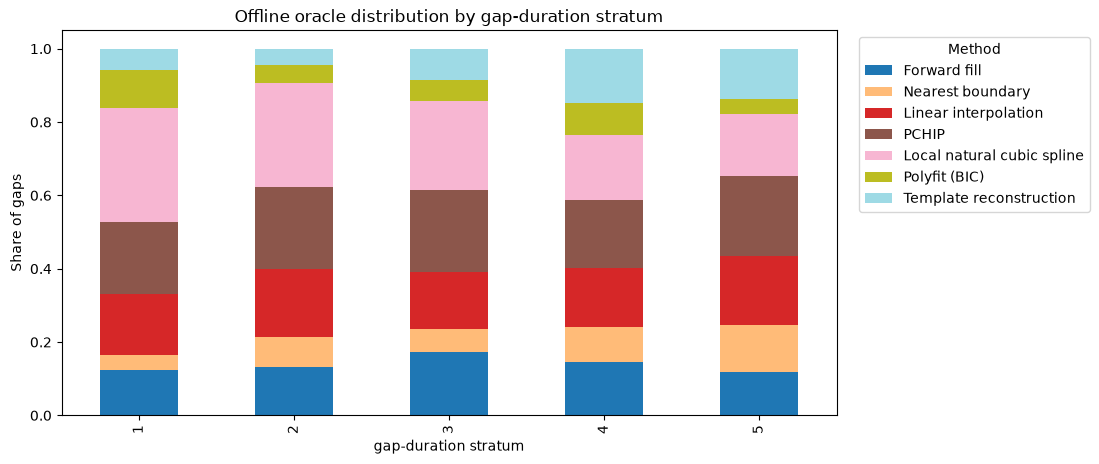

best_method_by_nrmse,forward_fill,nearest_boundary,linear,pchip,local_natural_cubic_spline,polyfit_bic,template
duration_stratum,,,,,,,
1,12.5,4.1,16.6,19.7,30.9,10.3,5.9
2,13.1,8.1,18.8,22.2,28.4,5.0,4.4
3,17.2,6.2,15.6,22.5,24.1,5.9,8.4
4,14.7,9.4,16.2,18.4,17.8,8.8,14.7
5,11.9,12.9,18.8,21.6,16.9,4.1,13.8


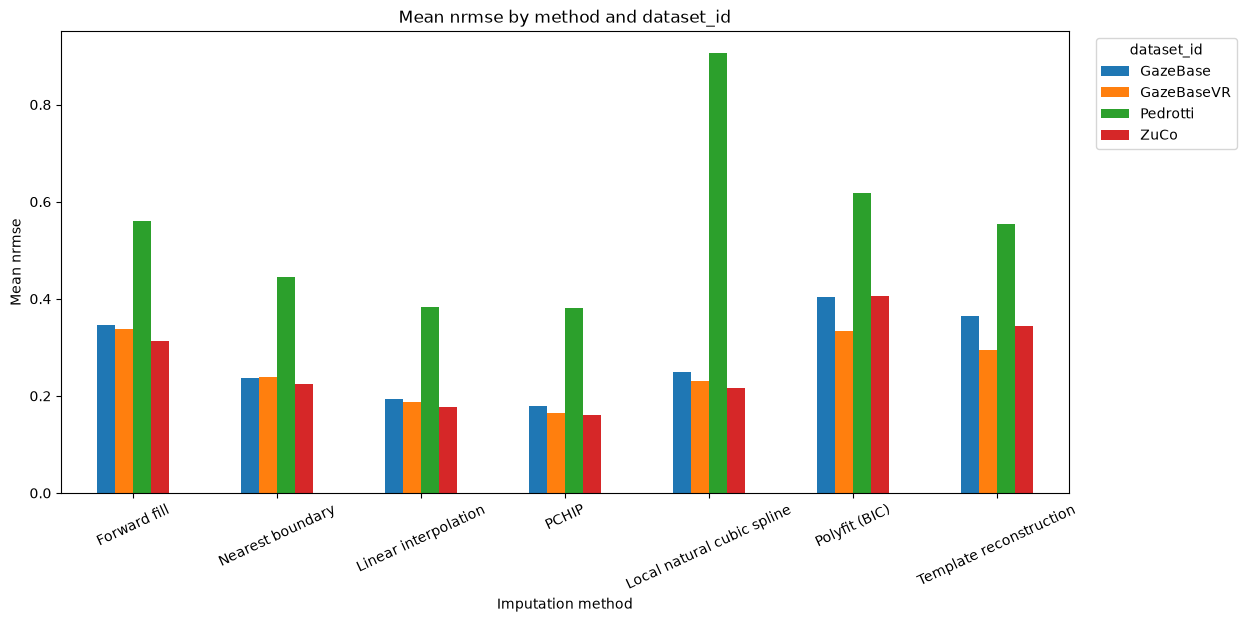

dataset_id,GazeBase,GazeBaseVR,Pedrotti,ZuCo
Forward fill,0.3462,0.3370,0.5612,0.3137
Nearest boundary,0.2364,0.2381,0.4442,0.2252
Linear interpolation,0.1944,0.1875,0.3839,0.1781
PCHIP,0.1791,0.1653,0.3818,0.1603
Local natural cubic spline,0.2491,0.2306,0.9063,0.2160
Polyfit (BIC),0.4042,0.3332,0.6180,0.4062
Template reconstruction,0.3654,0.2949,0.5538,0.3440


In [4]:
_, oracle_by_duration = plot_oracle_distribution(
    gaps, METHODS, group_column='duration_stratum', oracle_column=ORACLE_COLUMN,
    method_labels=METHOD_LABELS, group_label='gap-duration stratum',
)
plt.show()
display((100 * oracle_by_duration).round(1))

_, mean_errors = plot_mean_method_error(
    gaps, METHODS, group_column='dataset_id', method_labels=METHOD_LABELS,
)
plt.show()
display(mean_errors.round(4))